# Tabular Benchmark Suite With Learned Superposition Activations

This notebook extends notebook 06 to two additional offline sklearn datasets: **Wine** and **Breast Cancer**. Each dataset gets the same flow so the learned superposition activations can be compared consistently across tasks.

In [1]:
import sys
from pathlib import Path

for _p in (Path.cwd(), Path.cwd().parent):
    if (_p / "qfun").is_dir():
        _root = str(_p.resolve())
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break

from qfun.datasets import load_classification_dataset, prepare_classification_split
from qfun.qfan._classification_benchmarks import (
    build_comparison_rows,
    display_baseline_suite,
    display_quantum_result,
    print_comparison_table,
    print_split_summary,
    plot_training_diagnostics,
    run_default_baseline_suite,
    run_quantum_experiment,
)

## Config

These defaults match the planned benchmark settings for the tabular suite.

In [2]:
data_seed = 7
test_size = 0.25

hidden_units = 4
n_qubits = 3
steps = 30
learning_rate = 0.05
log_every = 5
snapshot_interval = 5
eval_shots = 5_000

## Wine

This section runs the full benchmark flow on **Wine**: dataset summary, classical baselines, and all three superposition-activation classifiers.

In [3]:
wine_dataset = load_classification_dataset("wine")
wine_split = prepare_classification_split(
    wine_dataset,
    test_size=test_size,
    seed=data_seed,
    standardize=True,
)
wine_class_names = wine_split.target_names
print_split_summary(wine_dataset.name, wine_split)

Dataset: Wine
Classes: ['class_0', 'class_1', 'class_2']
Training set: 133 samples
Test set:     45 samples
Feature dimension: 13
Train class counts: [44 53 36]
Test class counts:  [15 18 12]


### Baselines

Logistic regression and sklearn MLP provide the classical reference points for the same split.

LogisticRegression
  accuracy = 0.9778
  macro-F1 = 0.9771
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        15
     class_1      1.000     0.944     0.971        18
     class_2      0.923     1.000     0.960        12

    accuracy                          0.978        45
   macro avg      0.974     0.981     0.977        45
weighted avg      0.979     0.978     0.978        45

MLPClassifier
  accuracy = 1.0000
  macro-F1 = 1.0000
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        15
     class_1      1.000     1.000     1.000        18
     class_2      1.000     1.000     1.000        12

    accuracy                          1.000        45
   macro avg      1.000     1.000     1.000        45
weighted avg      1.000     1.000     1.000        45



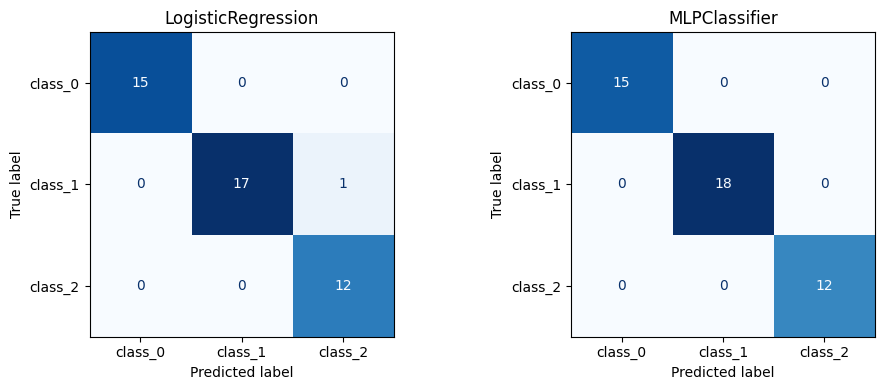

In [4]:
wine_baseline_results = run_default_baseline_suite(wine_split, seed=data_seed)
display_baseline_suite(wine_baseline_results, wine_class_names)

### Standard Superposition Activations

Training 30 epochs (logging every 5)…
  epoch 5/30  train_loss=0.893174
  epoch 10/30  train_loss=0.471474
  epoch 15/30  train_loss=0.226347
  epoch 20/30  train_loss=0.127232
  epoch 25/30  train_loss=0.083559
  epoch 30/30  train_loss=0.060702
Wine standard superposition activations
  train accuracy = 0.9850
  test accuracy  = 0.9111
  macro-F1       = 0.9092
  tracked units  = [0, 2]
              precision    recall  f1-score   support

     class_0      0.933     0.933     0.933        15
     class_1      0.941     0.889     0.914        18
     class_2      0.846     0.917     0.880        12

    accuracy                          0.911        45
   macro avg      0.907     0.913     0.909        45
weighted avg      0.913     0.911     0.911        45



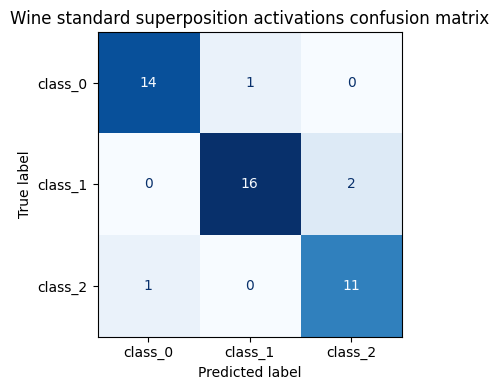

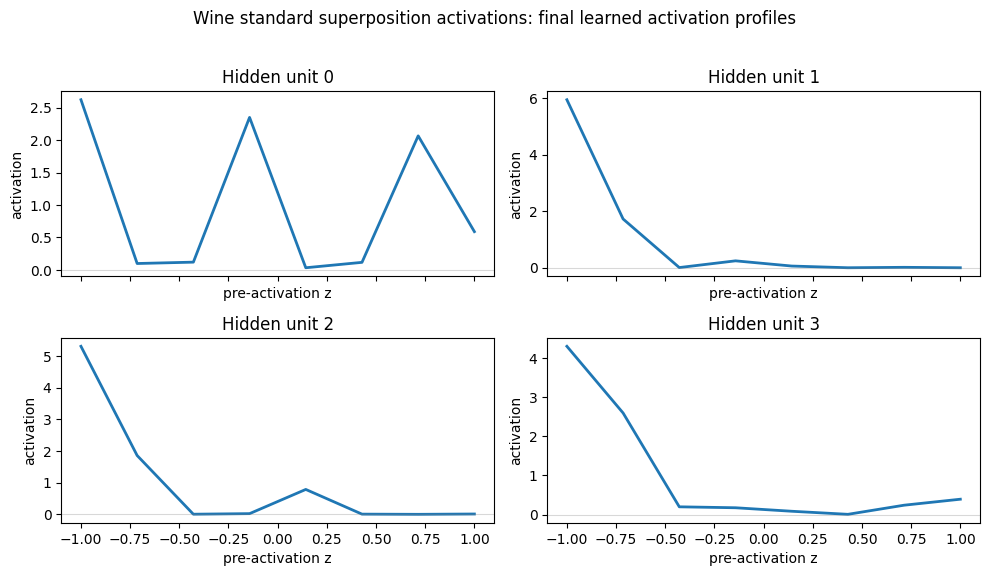

unit 0: exact-vs-measured L1 = 0.307345
unit 2: exact-vs-measured L1 = 0.122299


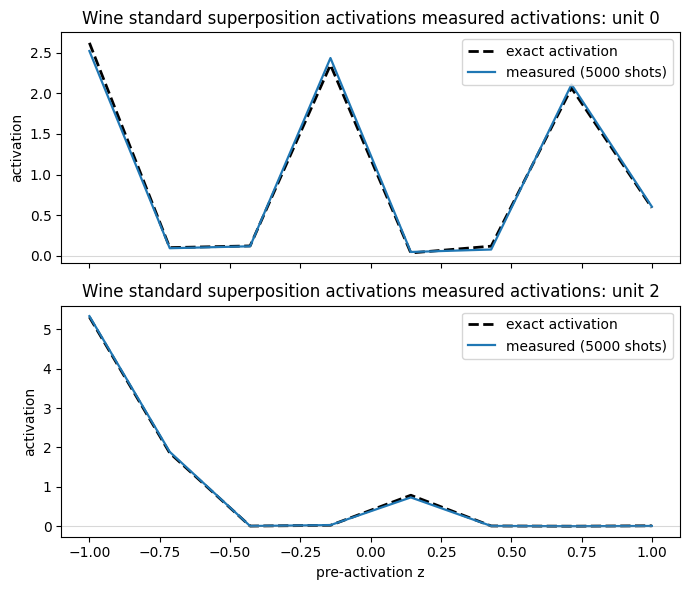

In [5]:
wine_standard_result = run_quantum_experiment(
    "standard",
    label="Wine standard superposition activations",
    split=wine_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(wine_standard_result, wine_class_names)

### Standard Training Process (Snapshots)

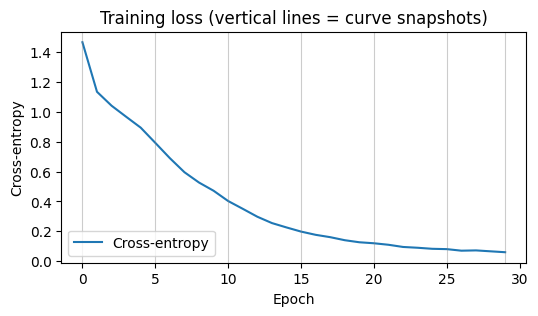

Epoch | loss at snapshot
   -1 | 1.46421
    2 | 1.0399
    5 | 0.791678
    8 | 0.526302
   11 | 0.350816
   14 | 0.226347
   17 | 0.161274
   20 | 0.120561
   23 | 0.0905344
   26 | 0.0709493
   29 | 0.0607022


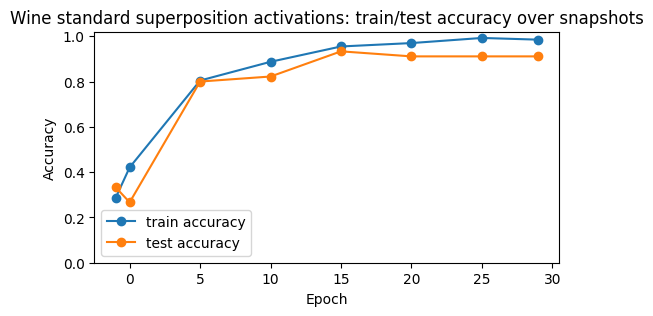

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


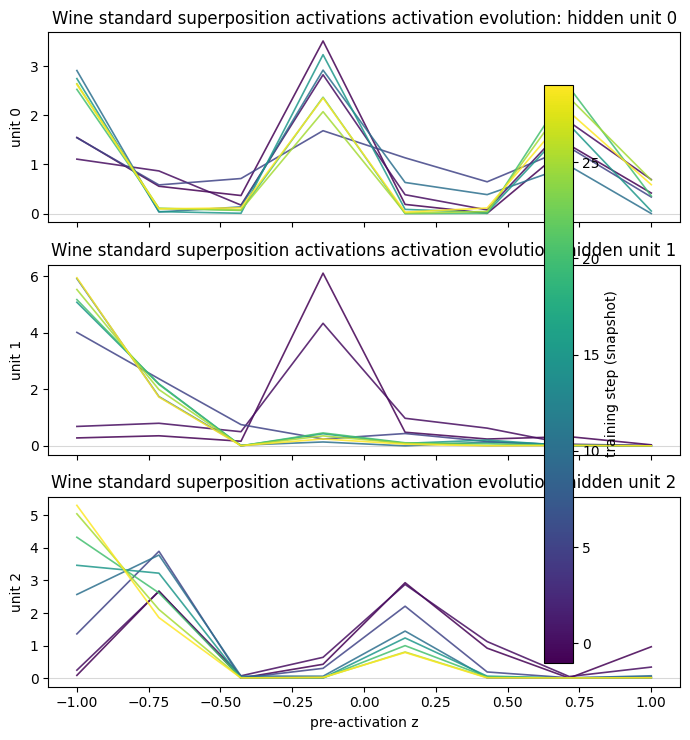

In [6]:
plot_training_diagnostics(wine_standard_result)

### Mode A Signed Superposition Activations

Training 30 epochs (logging every 5)…
  epoch 5/30  train_loss=0.869182
  epoch 10/30  train_loss=0.487646
  epoch 15/30  train_loss=0.224153
  epoch 20/30  train_loss=0.096020
  epoch 25/30  train_loss=0.036278
  epoch 30/30  train_loss=0.019020
Wine Mode A superposition activations
  train accuracy = 0.9925
  test accuracy  = 0.9556
  macro-F1       = 0.9533
  tracked units  = [0, 3]
              precision    recall  f1-score   support

     class_0      1.000     0.933     0.966        15
     class_1      1.000     0.944     0.971        18
     class_2      0.857     1.000     0.923        12

    accuracy                          0.956        45
   macro avg      0.952     0.959     0.953        45
weighted avg      0.962     0.956     0.957        45



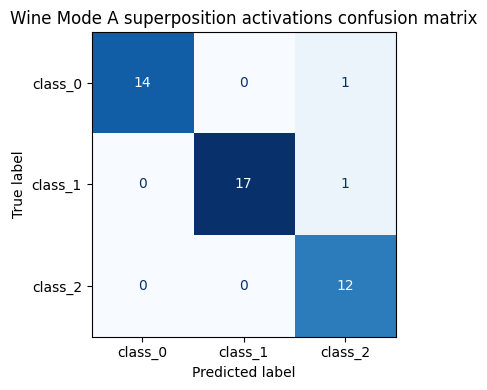

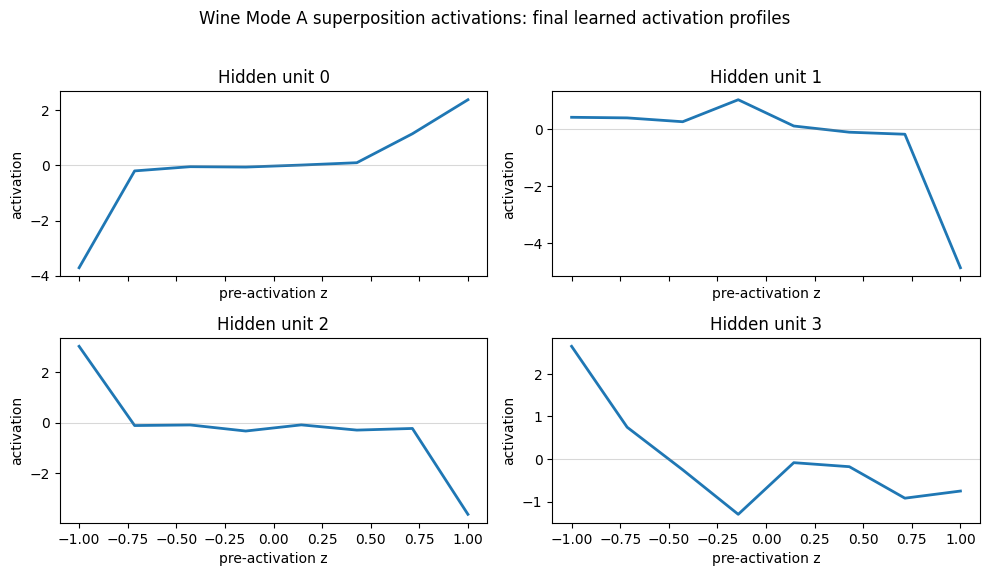

unit 0: exact-vs-measured L1 = 0.169956
  measured p_pos + p_neg = 1.000000
unit 3: exact-vs-measured L1 = 0.193247
  measured p_pos + p_neg = 1.000000


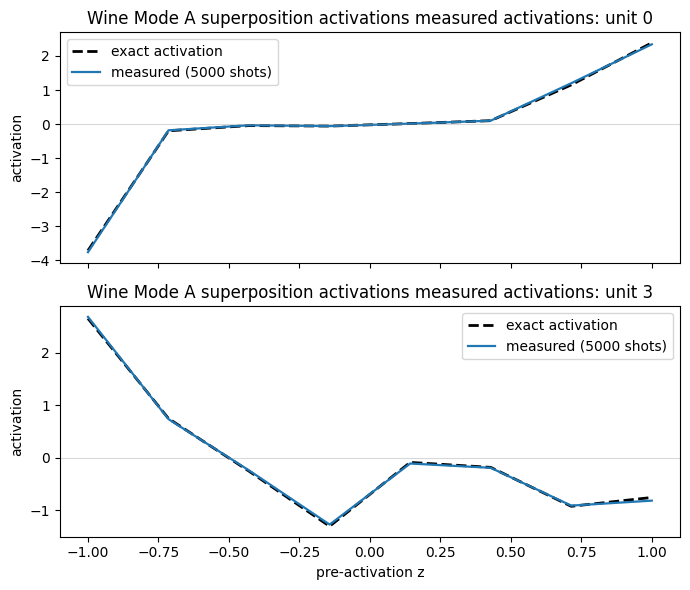

In [7]:
wine_mode_a_result = run_quantum_experiment(
    "mode_a",
    label="Wine Mode A superposition activations",
    split=wine_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(wine_mode_a_result, wine_class_names)

### Mode A Training Process (Snapshots)

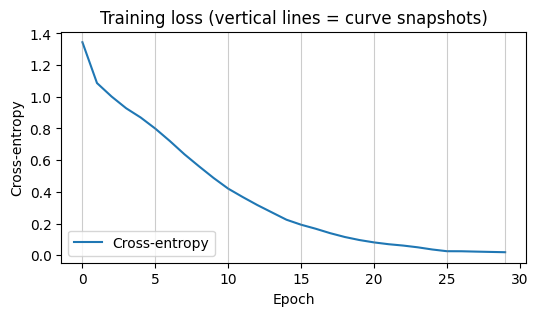

Epoch | loss at snapshot
   -1 | 1.34456
    2 | 1.0018
    5 | 0.799252
    8 | 0.561151
   11 | 0.36723
   14 | 0.224153
   17 | 0.139215
   20 | 0.0810498
   23 | 0.0500676
   26 | 0.0251059
   29 | 0.01902


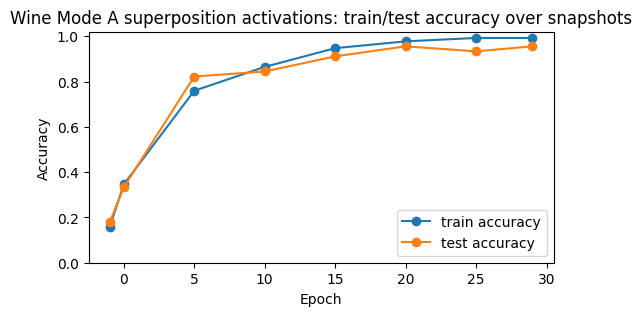

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


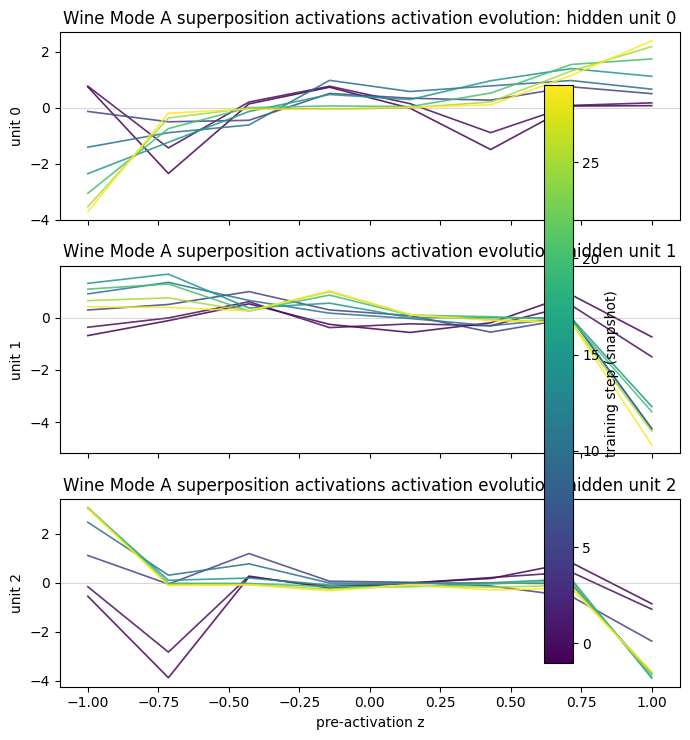

In [8]:
plot_training_diagnostics(wine_mode_a_result)

### Mode B Signed Superposition Activations

Training 30 epochs (logging every 5)…
  epoch 5/30  train_loss=0.482079
  epoch 10/30  train_loss=0.129486
  epoch 15/30  train_loss=0.044797
  epoch 20/30  train_loss=0.024265
  epoch 25/30  train_loss=0.007876
  epoch 30/30  train_loss=0.003043
Wine Mode B superposition activations
  train accuracy = 1.0000
  test accuracy  = 0.9333
  macro-F1       = 0.9343
  tracked units  = [2, 0]
              precision    recall  f1-score   support

     class_0      1.000     0.933     0.966        15
     class_1      0.941     0.889     0.914        18
     class_2      0.857     1.000     0.923        12

    accuracy                          0.933        45
   macro avg      0.933     0.941     0.934        45
weighted avg      0.938     0.933     0.934        45



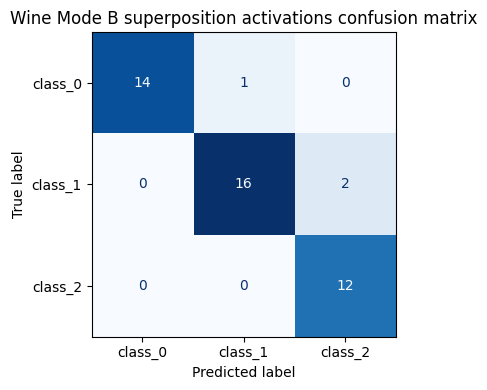

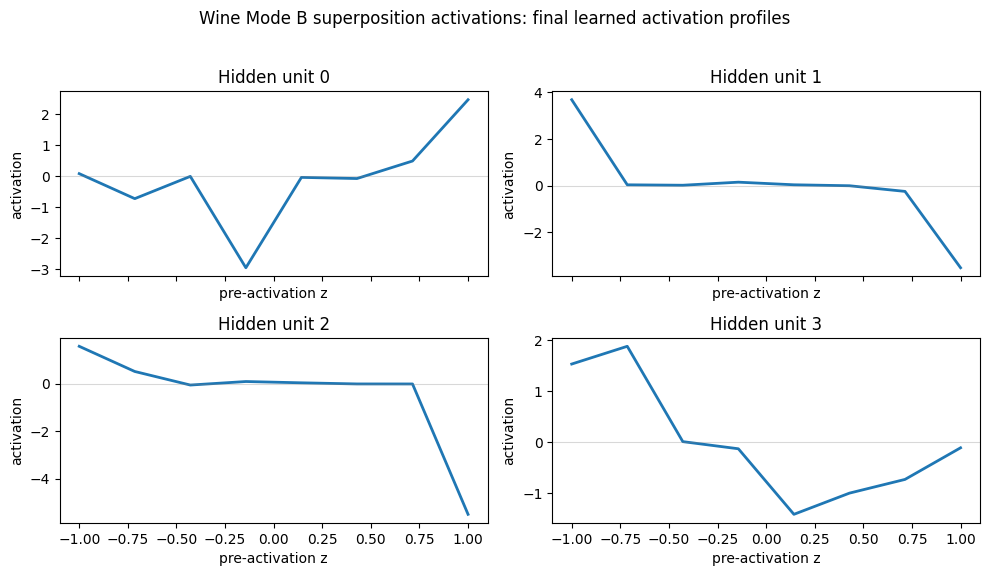

unit 2: exact-vs-measured L1 = 0.038300
  measured z_plus + z_minus = 1.000000
unit 0: exact-vs-measured L1 = 0.134571
  measured z_plus + z_minus = 1.000000


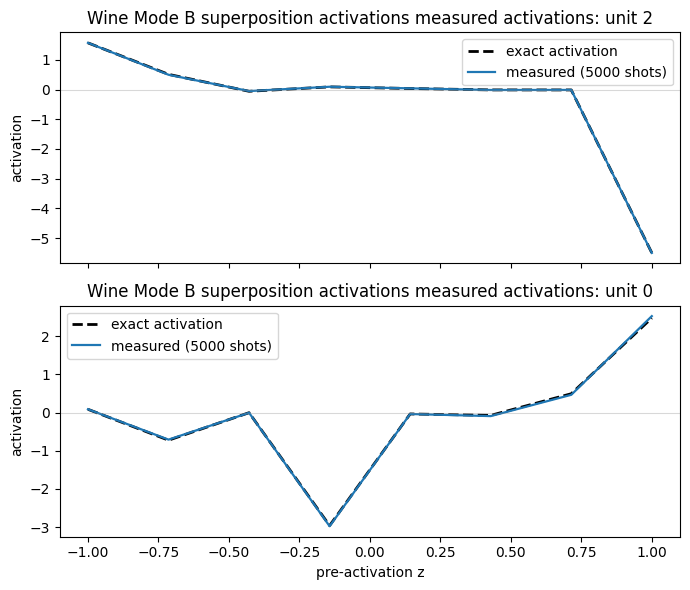

In [9]:
wine_mode_b_result = run_quantum_experiment(
    "mode_b",
    label="Wine Mode B superposition activations",
    split=wine_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(wine_mode_b_result, wine_class_names)

### Mode B Training Process (Snapshots)

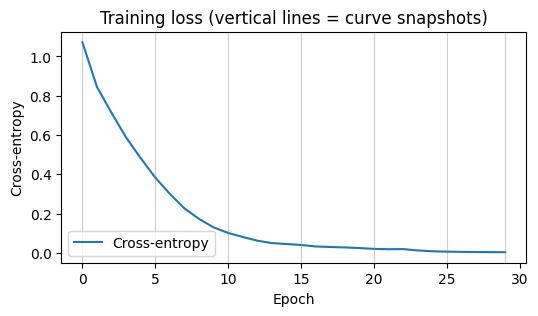

Epoch | loss at snapshot
   -1 | 1.07271
    2 | 0.712696
    5 | 0.383131
    8 | 0.17269
   11 | 0.0808378
   14 | 0.0447973
   17 | 0.029624
   20 | 0.0200832
   23 | 0.0121991
   26 | 0.00485958
   29 | 0.00304341


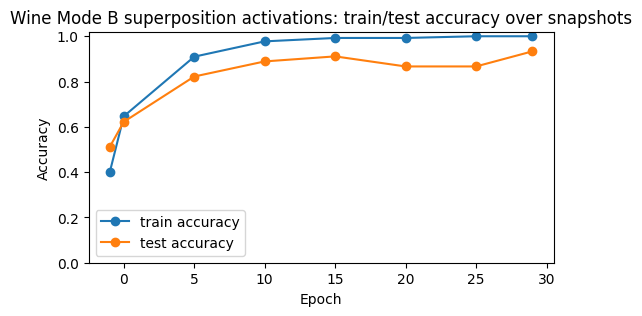

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


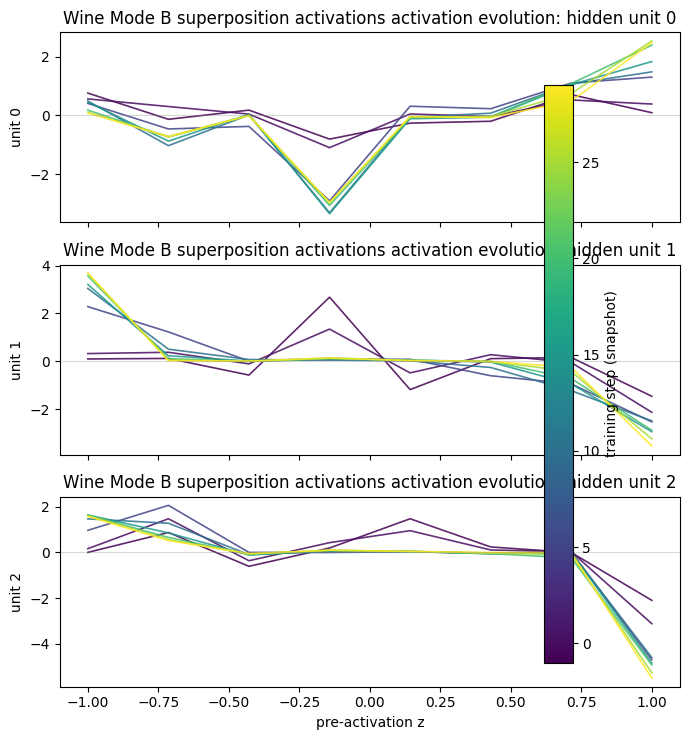

In [10]:
plot_training_diagnostics(wine_mode_b_result)

### Final Comparison

In [11]:
wine_comparison_rows = build_comparison_rows(
    wine_baseline_results,
    [wine_standard_result, wine_mode_a_result, wine_mode_b_result],
)
print_comparison_table(wine_comparison_rows)

Model                                   | Test accuracy | Macro-F1
----------------------------------------+---------------+---------
LogisticRegression                      |        0.9778 |   0.9771
MLPClassifier                           |        1.0000 |   1.0000
Wine standard superposition activations |        0.9111 |   0.9092
Wine Mode A superposition activations   |        0.9556 |   0.9533
Wine Mode B superposition activations   |        0.9333 |   0.9343


## Breast Cancer

This section runs the full benchmark flow on **Breast Cancer**: dataset summary, classical baselines, and all three superposition-activation classifiers.

In [12]:
breast_cancer_dataset = load_classification_dataset("breast_cancer")
breast_cancer_split = prepare_classification_split(
    breast_cancer_dataset,
    test_size=test_size,
    seed=data_seed,
    standardize=True,
)
breast_cancer_class_names = breast_cancer_split.target_names
print_split_summary(breast_cancer_dataset.name, breast_cancer_split)

Dataset: Breast Cancer
Classes: ['malignant', 'benign']
Training set: 426 samples
Test set:     143 samples
Feature dimension: 30
Train class counts: [159 267]
Test class counts:  [53 90]


### Baselines

Logistic regression and sklearn MLP provide the classical reference points for the same split.

LogisticRegression
  accuracy = 0.9790
  macro-F1 = 0.9776
              precision    recall  f1-score   support

   malignant      0.963     0.981     0.972        53
      benign      0.989     0.978     0.983        90

    accuracy                          0.979       143
   macro avg      0.976     0.979     0.978       143
weighted avg      0.979     0.979     0.979       143

MLPClassifier
  accuracy = 0.9790
  macro-F1 = 0.9776
              precision    recall  f1-score   support

   malignant      0.963     0.981     0.972        53
      benign      0.989     0.978     0.983        90

    accuracy                          0.979       143
   macro avg      0.976     0.979     0.978       143
weighted avg      0.979     0.979     0.979       143



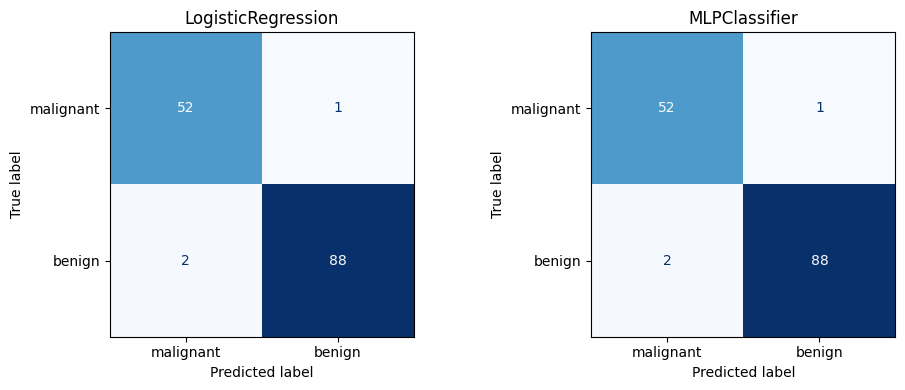

In [13]:
breast_cancer_baseline_results = run_default_baseline_suite(breast_cancer_split, seed=data_seed)
display_baseline_suite(breast_cancer_baseline_results, breast_cancer_class_names)

### Standard Superposition Activations

Training 30 epochs (logging every 5)…
  epoch 5/30  train_loss=0.425038
  epoch 10/30  train_loss=0.142257
  epoch 15/30  train_loss=0.069809
  epoch 20/30  train_loss=0.050679
  epoch 25/30  train_loss=0.035778
  epoch 30/30  train_loss=0.031295
Breast Cancer standard superposition activations
  train accuracy = 0.9977
  test accuracy  = 0.9510
  macro-F1       = 0.9485
  tracked units  = [0, 1]
              precision    recall  f1-score   support

   malignant      0.897     0.981     0.937        53
      benign      0.988     0.933     0.960        90

    accuracy                          0.951       143
   macro avg      0.942     0.957     0.948       143
weighted avg      0.954     0.951     0.951       143



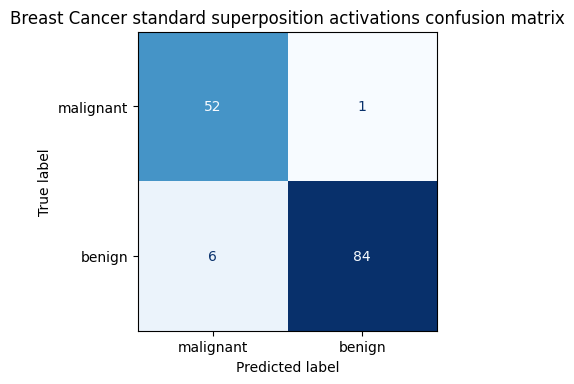

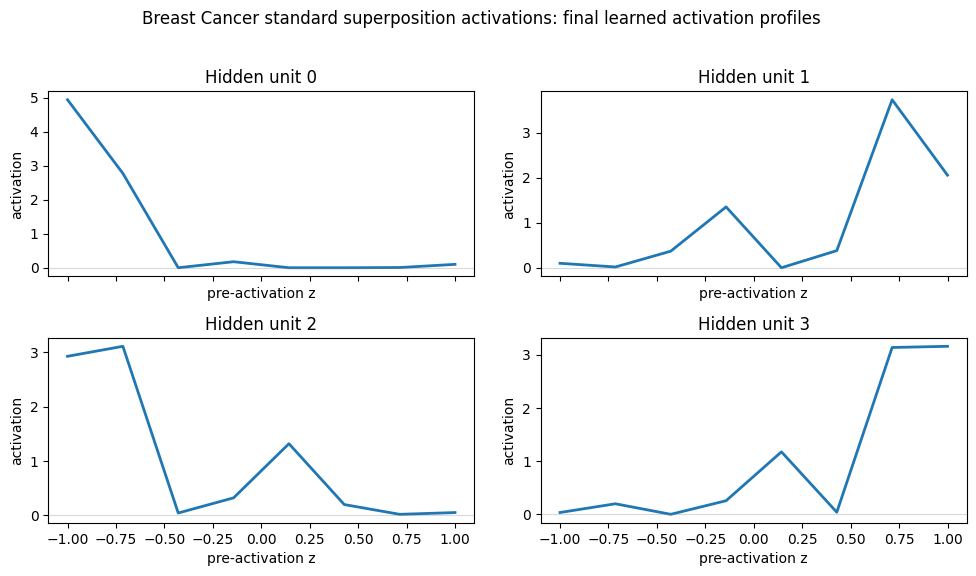

unit 0: exact-vs-measured L1 = 0.139551
unit 1: exact-vs-measured L1 = 0.254742


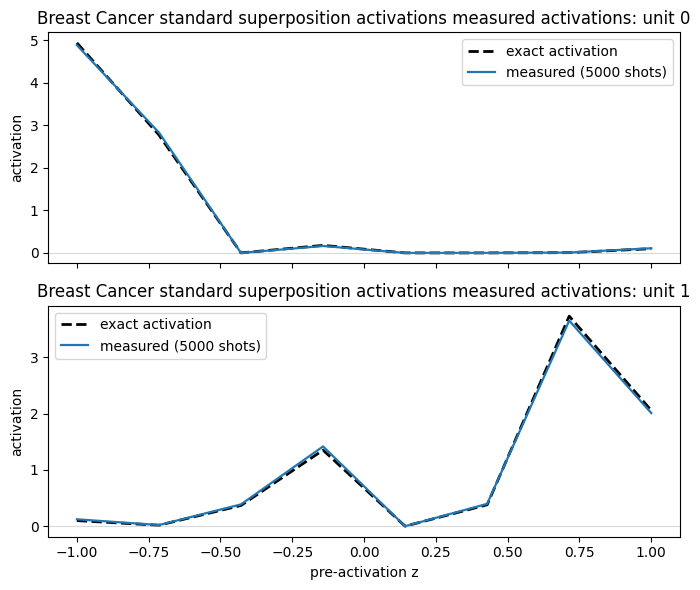

In [14]:
breast_cancer_standard_result = run_quantum_experiment(
    "standard",
    label="Breast Cancer standard superposition activations",
    split=breast_cancer_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(breast_cancer_standard_result, breast_cancer_class_names)

### Standard Training Process (Snapshots)

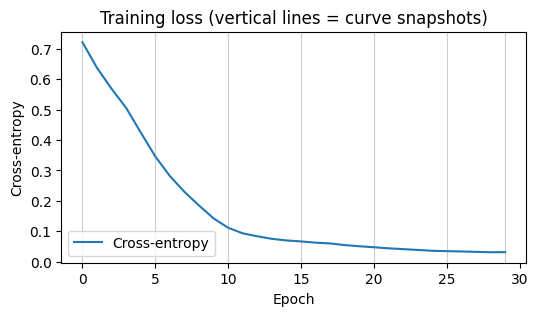

Epoch | loss at snapshot
   -1 | 0.721597
    2 | 0.568477
    5 | 0.345968
    8 | 0.184647
   11 | 0.0930993
   14 | 0.0698089
   17 | 0.0598878
   20 | 0.0473546
   23 | 0.0384842
   26 | 0.0336056
   29 | 0.0312945


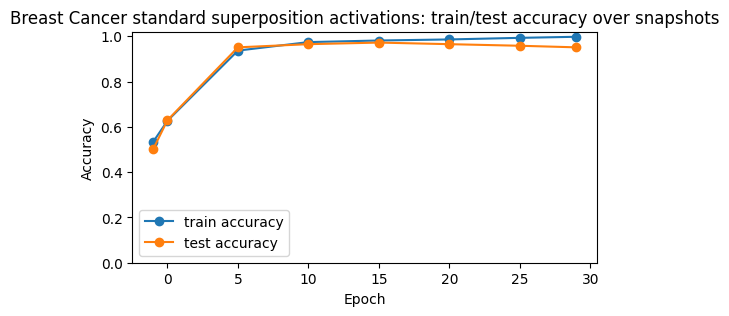

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


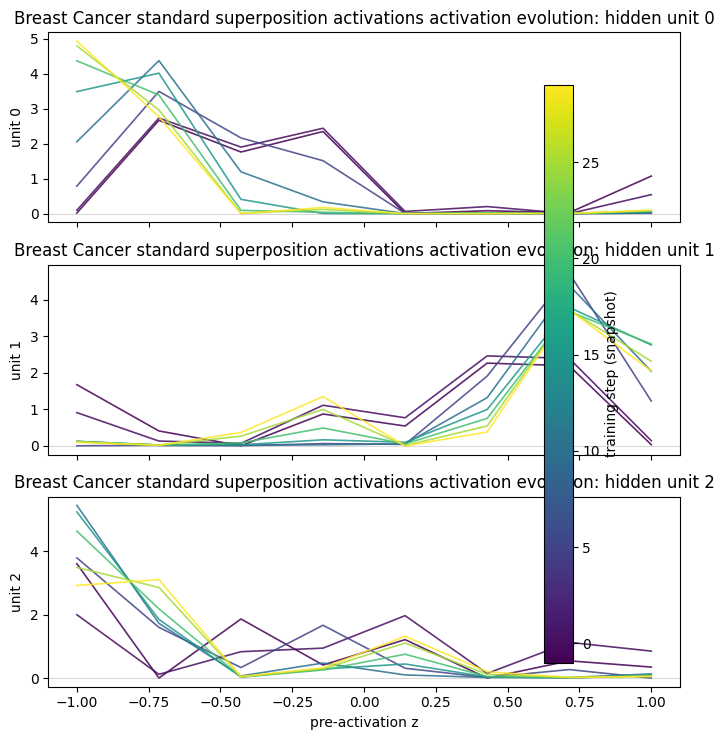

In [15]:
plot_training_diagnostics(breast_cancer_standard_result)

### Mode A Signed Superposition Activations

Training 30 epochs (logging every 5)…
  epoch 5/30  train_loss=0.468070
  epoch 10/30  train_loss=0.110117
  epoch 15/30  train_loss=0.071595
  epoch 20/30  train_loss=0.060769
  epoch 25/30  train_loss=0.046159
  epoch 30/30  train_loss=0.037146
Breast Cancer Mode A superposition activations
  train accuracy = 0.9906
  test accuracy  = 0.9790
  macro-F1       = 0.9776
  tracked units  = [1, 3]
              precision    recall  f1-score   support

   malignant      0.963     0.981     0.972        53
      benign      0.989     0.978     0.983        90

    accuracy                          0.979       143
   macro avg      0.976     0.979     0.978       143
weighted avg      0.979     0.979     0.979       143



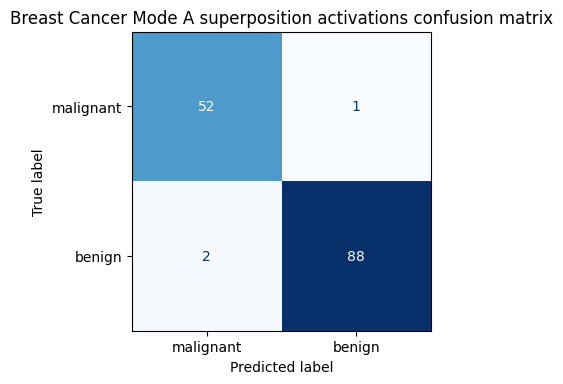

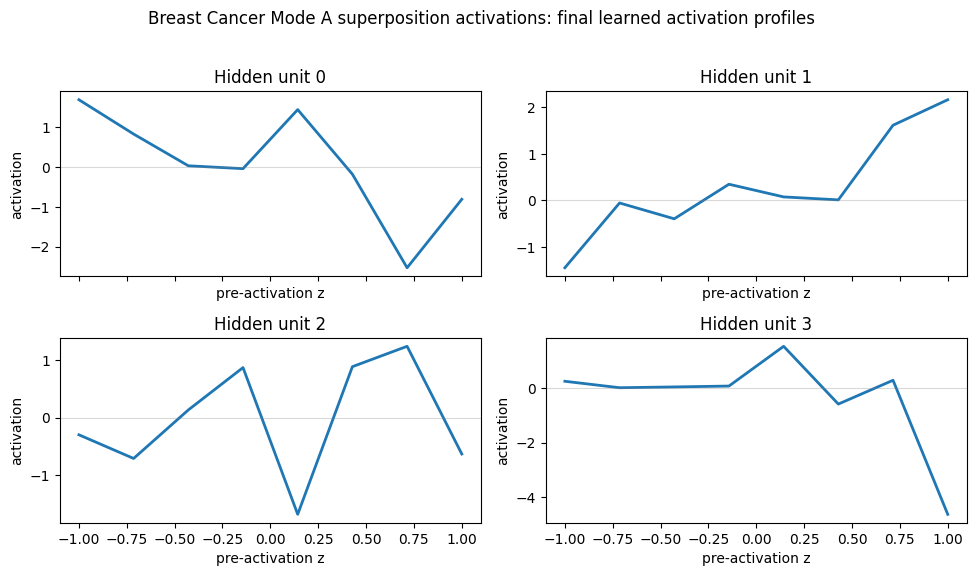

unit 1: exact-vs-measured L1 = 0.177242
  measured p_pos + p_neg = 1.000000
unit 3: exact-vs-measured L1 = 0.153494
  measured p_pos + p_neg = 1.000000


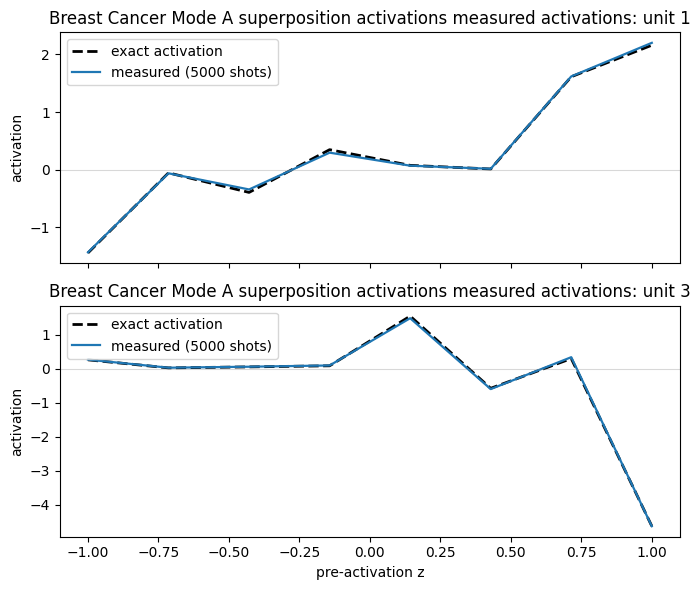

In [16]:
breast_cancer_mode_a_result = run_quantum_experiment(
    "mode_a",
    label="Breast Cancer Mode A superposition activations",
    split=breast_cancer_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(breast_cancer_mode_a_result, breast_cancer_class_names)

### Mode A Training Process (Snapshots)

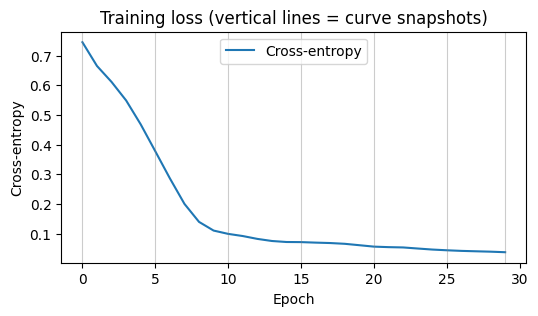

Epoch | loss at snapshot
   -1 | 0.74504
    2 | 0.61113
    5 | 0.377476
    8 | 0.139379
   11 | 0.0916995
   14 | 0.0715947
   17 | 0.0680971
   20 | 0.0559951
   23 | 0.0496368
   26 | 0.0416517
   29 | 0.0371457


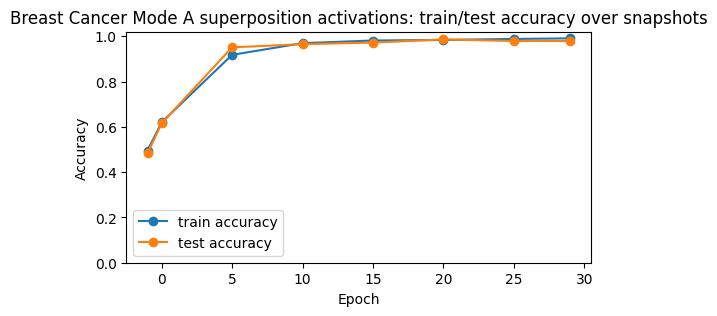

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


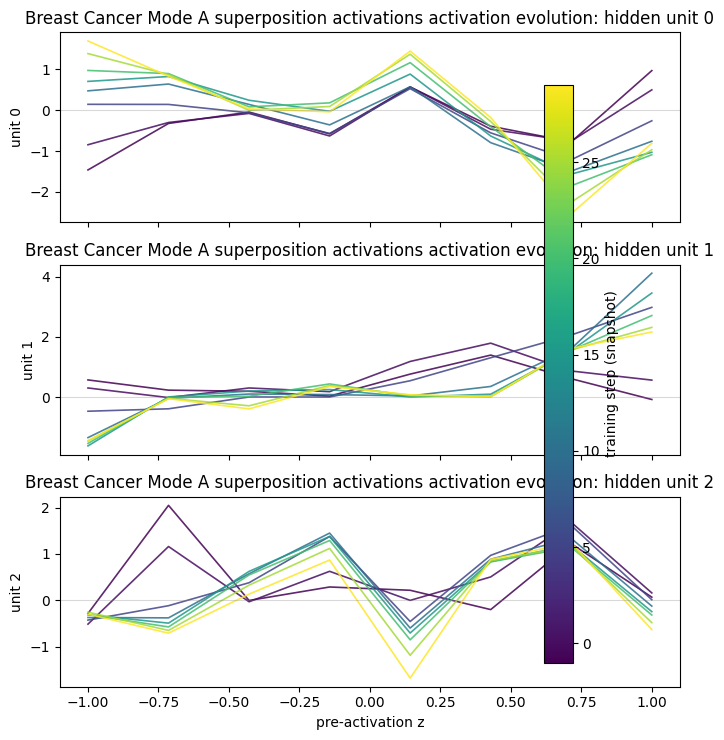

In [17]:
plot_training_diagnostics(breast_cancer_mode_a_result)

### Mode B Signed Superposition Activations

Training 30 epochs (logging every 5)…
  epoch 5/30  train_loss=0.325141
  epoch 10/30  train_loss=0.081661
  epoch 15/30  train_loss=0.062483
  epoch 20/30  train_loss=0.043706
  epoch 25/30  train_loss=0.032729
  epoch 30/30  train_loss=0.026235
Breast Cancer Mode B superposition activations
  train accuracy = 0.9953
  test accuracy  = 0.9720
  macro-F1       = 0.9702
  tracked units  = [0, 3]
              precision    recall  f1-score   support

   malignant      0.945     0.981     0.963        53
      benign      0.989     0.967     0.978        90

    accuracy                          0.972       143
   macro avg      0.967     0.974     0.970       143
weighted avg      0.973     0.972     0.972       143



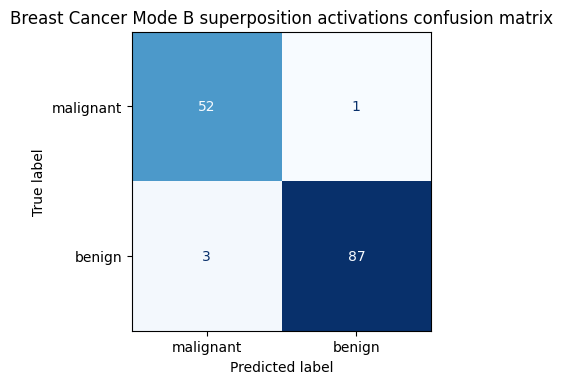

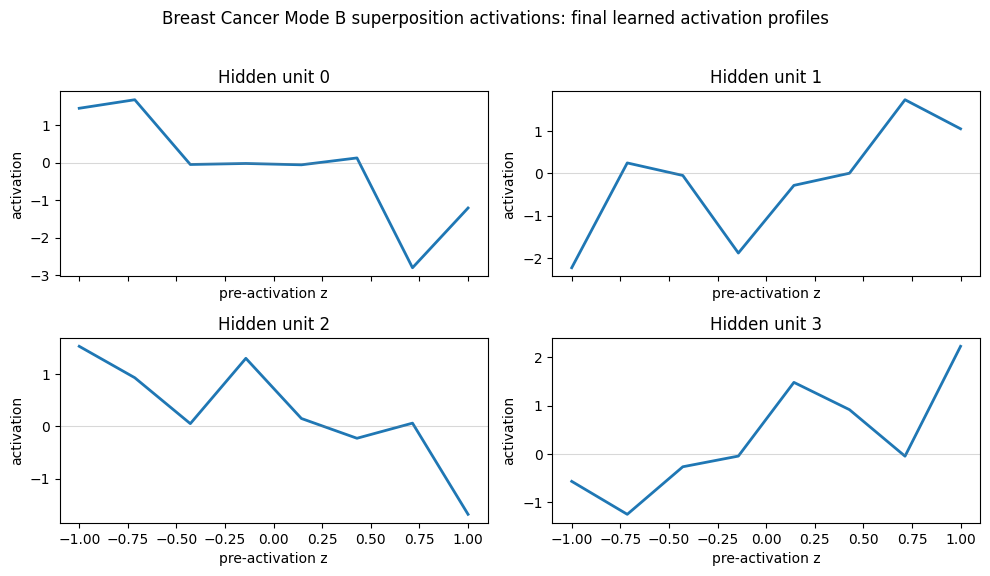

unit 0: exact-vs-measured L1 = 0.100436
  measured z_plus + z_minus = 1.000000
unit 3: exact-vs-measured L1 = 0.088851
  measured z_plus + z_minus = 1.000000


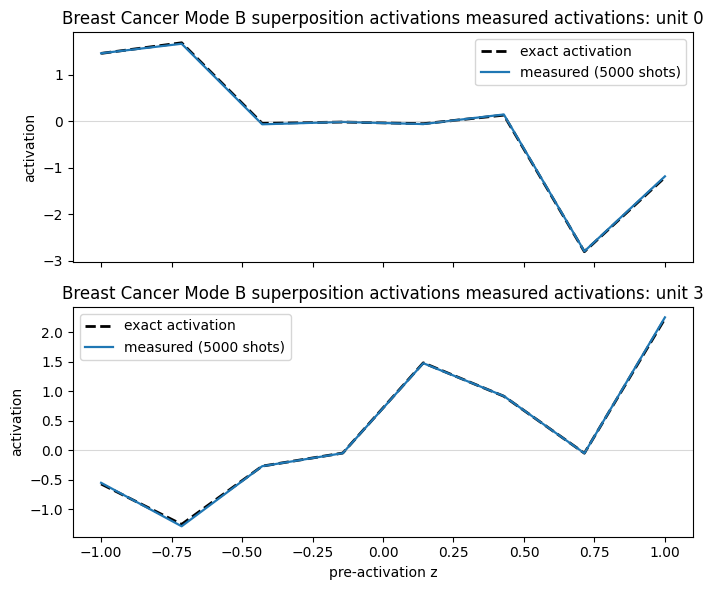

In [18]:
breast_cancer_mode_b_result = run_quantum_experiment(
    "mode_b",
    label="Breast Cancer Mode B superposition activations",
    split=breast_cancer_split,
    hidden_units=hidden_units,
    n_qubits=n_qubits,
    steps=steps,
    learning_rate=learning_rate,
    seed=data_seed,
    log_every=log_every,
    snapshot_interval=snapshot_interval,
    eval_shots=eval_shots,
)
display_quantum_result(breast_cancer_mode_b_result, breast_cancer_class_names)

### Mode B Training Process (Snapshots)

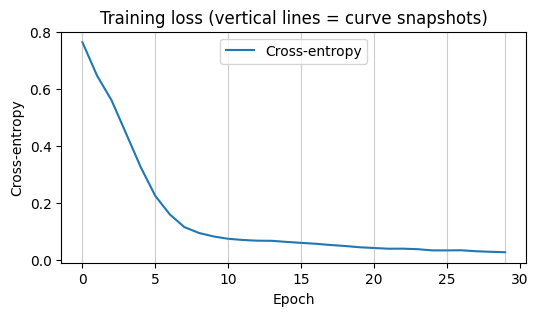

Epoch | loss at snapshot
   -1 | 0.763859
    2 | 0.55971
    5 | 0.22418
    8 | 0.0938034
   11 | 0.0692313
   14 | 0.0624829
   17 | 0.0516826
   20 | 0.0410718
   23 | 0.0369318
   26 | 0.0330585
   29 | 0.0262346


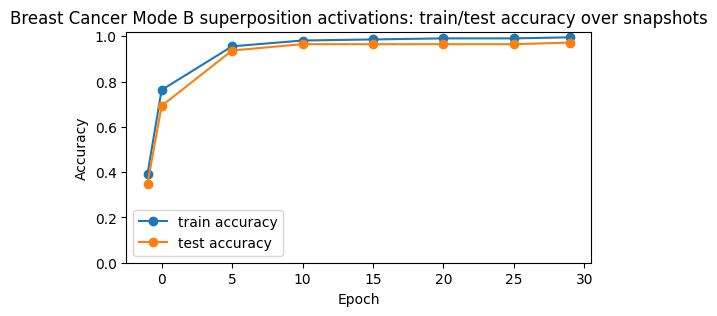

/Users/kooshan/Desktop/QFun/qfun/qfan/_classification_benchmarks.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


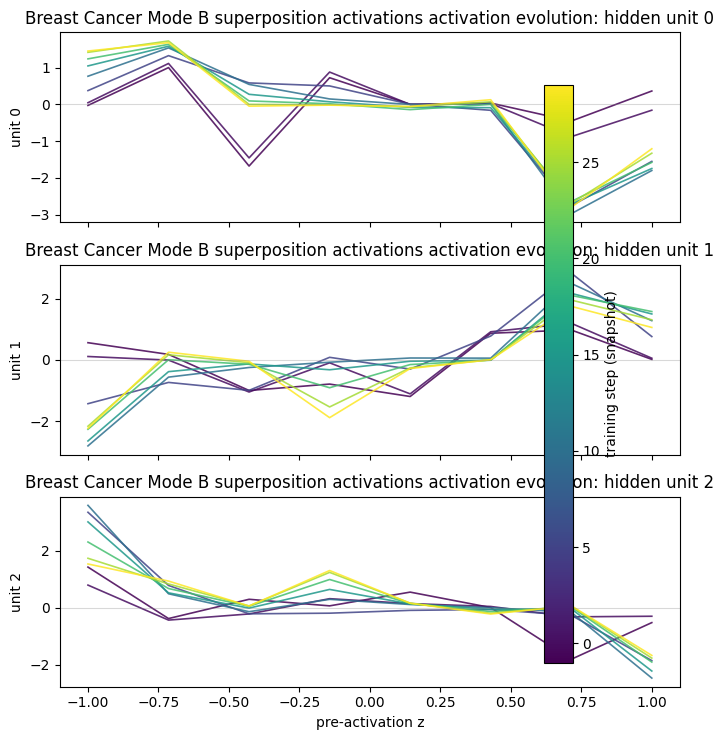

In [19]:
plot_training_diagnostics(breast_cancer_mode_b_result)

### Final Comparison

In [20]:
breast_cancer_comparison_rows = build_comparison_rows(
    breast_cancer_baseline_results,
    [breast_cancer_standard_result, breast_cancer_mode_a_result, breast_cancer_mode_b_result],
)
print_comparison_table(breast_cancer_comparison_rows)

Model                                            | Test accuracy | Macro-F1
-------------------------------------------------+---------------+---------
LogisticRegression                               |        0.9790 |   0.9776
MLPClassifier                                    |        0.9790 |   0.9776
Breast Cancer standard superposition activations |        0.9510 |   0.9485
Breast Cancer Mode A superposition activations   |        0.9790 |   0.9776
Breast Cancer Mode B superposition activations   |        0.9720 |   0.9702
